## Run this first , ignoring running from prewvious chapters import and download the GPT

In [ ]:
# #Dependiences , Previous Chapters
# # Copyright (c) Sebastian Raschka under Apache License 2.0 (see LICENSE.txt).
# # Source for "Build a Large Language Model From Scratch"
# #   - https://www.manning.com/books/build-a-large-language-model-from-scratch
# # Code: https://github.com/rasbt/LLMs-from-scratch
# #
# # This file collects all the relevant code that we covered thus far
# # throughout Chapters 2-4.
# # This file can be run as a standalone script.

# import tiktoken
# import torch
# import torch.nn as nn
# from torch.utils.data import Dataset, DataLoader

# #####################################
# # Chapter 2
# #####################################


# class GPTDatasetV1(Dataset):
#     def __init__(self, txt, tokenizer, max_length, stride):
#         self.input_ids = []
#         self.target_ids = []

#         # Tokenize the entire text
#         token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

#         # Use a sliding window to chunk the book into overlapping sequences of max_length
#         for i in range(0, len(token_ids) - max_length, stride):
#             input_chunk = token_ids[i:i + max_length]
#             target_chunk = token_ids[i + 1: i + max_length + 1]
#             self.input_ids.append(torch.tensor(input_chunk))
#             self.target_ids.append(torch.tensor(target_chunk))

#     def __len__(self):
#         return len(self.input_ids)

#     def __getitem__(self, idx):
#         return self.input_ids[idx], self.target_ids[idx]


# def create_dataloader_v1(txt, batch_size=4, max_length=256,
#                          stride=128, shuffle=True, drop_last=True, num_workers=0):
#     # Initialize the tokenizer
#     tokenizer = tiktoken.get_encoding("gpt2")

#     # Create dataset
#     dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

#     # Create dataloader
#     dataloader = DataLoader(
#         dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)

#     return dataloader


# #####################################
# # Chapter 3
# #####################################
# class MultiHeadAttention(nn.Module):
#     def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
#         super().__init__()
#         assert d_out % num_heads == 0, "d_out must be divisible by n_heads"

#         self.d_out = d_out
#         self.num_heads = num_heads
#         self.head_dim = d_out // num_heads  # Reduce the projection dim to match desired output dim

#         self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
#         self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
#         self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
#         self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
#         self.dropout = nn.Dropout(dropout)
#         self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

#     def forward(self, x):
#         b, num_tokens, d_in = x.shape

#         keys = self.W_key(x)  # Shape: (b, num_tokens, d_out)
#         queries = self.W_query(x)
#         values = self.W_value(x)

#         # We implicitly split the matrix by adding a `num_heads` dimension
#         # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
#         keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
#         values = values.view(b, num_tokens, self.num_heads, self.head_dim)
#         queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

#         # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
#         keys = keys.transpose(1, 2)
#         queries = queries.transpose(1, 2)
#         values = values.transpose(1, 2)

#         # Compute scaled dot-product attention (aka self-attention) with a causal mask
#         attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

#         # Original mask truncated to the number of tokens and converted to boolean
#         mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

#         # Use the mask to fill attention scores
#         attn_scores.masked_fill_(mask_bool, -torch.inf)

#         attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
#         attn_weights = self.dropout(attn_weights)

#         # Shape: (b, num_tokens, num_heads, head_dim)
#         context_vec = (attn_weights @ values).transpose(1, 2)

#         # Combine heads, where self.d_out = self.num_heads * self.head_dim
#         context_vec = context_vec.reshape(b, num_tokens, self.d_out)
#         context_vec = self.out_proj(context_vec)  # optional projection

#         return context_vec


# #####################################
# # Chapter 4
# #####################################
# class LayerNorm(nn.Module):
#     def __init__(self, emb_dim):
#         super().__init__()
#         self.eps = 1e-5
#         self.scale = nn.Parameter(torch.ones(emb_dim))
#         self.shift = nn.Parameter(torch.zeros(emb_dim))

#     def forward(self, x):
#         mean = x.mean(dim=-1, keepdim=True)
#         var = x.var(dim=-1, keepdim=True, unbiased=False)
#         norm_x = (x - mean) / torch.sqrt(var + self.eps)
#         return self.scale * norm_x + self.shift


# class GELU(nn.Module):
#     def __init__(self):
#         super().__init__()

#     def forward(self, x):
#         return 0.5 * x * (1 + torch.tanh(
#             torch.sqrt(torch.tensor(2.0 / torch.pi)) *
#             (x + 0.044715 * torch.pow(x, 3))
#         ))


# class FeedForward(nn.Module):
#     def __init__(self, cfg):
#         super().__init__()
#         self.layers = nn.Sequential(
#             nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
#             GELU(),
#             nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
#         )

#     def forward(self, x):
#         return self.layers(x)


# class TransformerBlock(nn.Module):
#     def __init__(self, cfg):
#         super().__init__()
#         self.att = MultiHeadAttention(
#             d_in=cfg["emb_dim"],
#             d_out=cfg["emb_dim"],
#             context_length=cfg["context_length"],
#             num_heads=cfg["n_heads"],
#             dropout=cfg["drop_rate"],
#             qkv_bias=cfg["qkv_bias"])
#         self.ff = FeedForward(cfg)
#         self.norm1 = LayerNorm(cfg["emb_dim"])
#         self.norm2 = LayerNorm(cfg["emb_dim"])
#         self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

#     def forward(self, x):
#         # Shortcut connection for attention block
#         shortcut = x
#         x = self.norm1(x)
#         x = self.att(x)   # Shape [batch_size, num_tokens, emb_size]
#         x = self.drop_shortcut(x)
#         x = x + shortcut  # Add the original input back

#         # Shortcut connection for feed-forward block
#         shortcut = x
#         x = self.norm2(x)
#         x = self.ff(x)
#         x = self.drop_shortcut(x)
#         x = x + shortcut  # Add the original input back

#         return x


# class GPTModel(nn.Module):
#     def __init__(self, cfg):
#         super().__init__()
#         self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
#         self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
#         self.drop_emb = nn.Dropout(cfg["drop_rate"])

#         self.trf_blocks = nn.Sequential(
#             *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

#         self.final_norm = LayerNorm(cfg["emb_dim"])
#         self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

#     def forward(self, in_idx):
#         batch_size, seq_len = in_idx.shape
#         tok_embeds = self.tok_emb(in_idx)
#         pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
#         x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
#         x = self.drop_emb(x)
#         x = self.trf_blocks(x)
#         x = self.final_norm(x)
#         logits = self.out_head(x)
#         return logits


# def generate_text_simple(model, idx, max_new_tokens, context_size):
#     # idx is (B, T) array of indices in the current context
#     for _ in range(max_new_tokens):

#         # Crop current context if it exceeds the supported context size
#         # E.g., if LLM supports only 5 tokens, and the context size is 10
#         # then only the last 5 tokens are used as context
#         idx_cond = idx[:, -context_size:]

#         # Get the predictions
#         with torch.no_grad():
#             logits = model(idx_cond)

#         # Focus only on the last time step
#         # (batch, n_token, vocab_size) becomes (batch, vocab_size)
#         logits = logits[:, -1, :]

#         # Get the idx of the vocab entry with the highest logits value
#         idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch, 1)

#         # Append sampled index to the running sequence
#         idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

#     return idx


In [ ]:
# # Copyright (c) Sebastian Raschka under Apache License 2.0 (see LICENSE.txt).
# # Source for "Build a Large Language Model From Scratch"
# #   - https://www.manning.com/books/build-a-large-language-model-from-scratch
# # Code: https://github.com/rasbt/LLMs-from-scratch


# import os

# import requests
# import json
# import numpy as np
# import tensorflow as tf
# from tqdm import tqdm


# def download_and_load_gpt2(model_size, models_dir):
#     # Validate model size
#     allowed_sizes = ("124M", "355M", "774M", "1558M")
#     if model_size not in allowed_sizes:
#         raise ValueError(f"Model size not in {allowed_sizes}")

#     # Define paths
#     model_dir = os.path.join(models_dir, model_size)
#     base_url = "https://openaipublic.blob.core.windows.net/gpt-2/models"
#     backup_base_url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/gpt2"
#     filenames = [
#         "checkpoint", "encoder.json", "hparams.json",
#         "model.ckpt.data-00000-of-00001", "model.ckpt.index",
#         "model.ckpt.meta", "vocab.bpe"
#     ]

#     # Download files
#     os.makedirs(model_dir, exist_ok=True)
#     for filename in filenames:
#         file_url = os.path.join(base_url, model_size, filename)
#         backup_url = os.path.join(backup_base_url, model_size, filename)
#         file_path = os.path.join(model_dir, filename)
#         download_file(file_url, file_path, backup_url)

#     # Load settings and params
#     tf_ckpt_path = tf.train.latest_checkpoint(model_dir)
#     settings = json.load(open(os.path.join(model_dir, "hparams.json"), "r", encoding="utf-8"))
#     params = load_gpt2_params_from_tf_ckpt(tf_ckpt_path, settings)

#     return settings, params


# def download_file(url, destination, backup_url=None):
#     def _attempt_download(download_url):
#         response = requests.get(download_url, stream=True, timeout=60)
#         response.raise_for_status()

#         file_size = int(response.headers.get("Content-Length", 0))

#         # Check if file exists and has same size
#         if os.path.exists(destination):
#             file_size_local = os.path.getsize(destination)
#             if file_size and file_size == file_size_local:
#                 print(f"File already exists and is up-to-date: {destination}")
#                 return True

#         block_size = 1024  # 1 KB
#         desc = os.path.basename(download_url)
#         with tqdm(total=file_size, unit="iB", unit_scale=True, desc=desc) as progress_bar:
#             with open(destination, "wb") as file:
#                 for chunk in response.iter_content(chunk_size=block_size):
#                     if chunk:
#                         file.write(chunk)
#                         progress_bar.update(len(chunk))
#         return True

#     try:
#         if _attempt_download(url):
#             return
#     except requests.exceptions.RequestException:
#         if backup_url is not None:
#             print(f"Primary URL ({url}) failed. Attempting backup URL: {backup_url}")
#             try:
#                 if _attempt_download(backup_url):
#                     return
#             except requests.exceptions.RequestException:
#                 pass

#         error_message = (
#             f"Failed to download from both primary URL ({url})"
#             f"{' and backup URL (' + backup_url + ')' if backup_url else ''}."
#             "\nCheck your internet connection or the file availability.\n"
#             "For help, visit: https://github.com/rasbt/LLMs-from-scratch/discussions/273"
#         )
#         print(error_message)
#     except Exception as e:
#         print(f"An unexpected error occurred: {e}")


# # Alternative way using `requests`
# """
# def download_file(url, destination):
#     # Send a GET request to download the file in streaming mode
#     response = requests.get(url, stream=True)

#     # Get the total file size from headers, defaulting to 0 if not present
#     file_size = int(response.headers.get("content-length", 0))

#     # Check if file exists and has the same size
#     if os.path.exists(destination):
#         file_size_local = os.path.getsize(destination)
#         if file_size == file_size_local:
#             print(f"File already exists and is up-to-date: {destination}")
#             return

#     # Define the block size for reading the file
#     block_size = 1024  # 1 Kilobyte

#     # Initialize the progress bar with total file size
#     progress_bar_description = url.split("/")[-1]  # Extract filename from URL
#     with tqdm(total=file_size, unit="iB", unit_scale=True, desc=progress_bar_description) as progress_bar:
#         # Open the destination file in binary write mode
#         with open(destination, "wb") as file:
#             # Iterate over the file data in chunks
#             for chunk in response.iter_content(block_size):
#                 progress_bar.update(len(chunk))  # Update progress bar
#                 file.write(chunk)  # Write the chunk to the file
# """


# def load_gpt2_params_from_tf_ckpt(ckpt_path, settings):
#     # Initialize parameters dictionary with empty blocks for each layer
#     params = {"blocks": [{} for _ in range(settings["n_layer"])]}

#     # Iterate over each variable in the checkpoint
#     for name, _ in tf.train.list_variables(ckpt_path):
#         # Load the variable and remove singleton dimensions
#         variable_array = np.squeeze(tf.train.load_variable(ckpt_path, name))

#         # Process the variable name to extract relevant parts
#         variable_name_parts = name.split("/")[1:]  # Skip the 'model/' prefix

#         # Identify the target dictionary for the variable
#         target_dict = params
#         if variable_name_parts[0].startswith("h"):
#             layer_number = int(variable_name_parts[0][1:])
#             target_dict = params["blocks"][layer_number]

#         # Recursively access or create nested dictionaries
#         for key in variable_name_parts[1:-1]:
#             target_dict = target_dict.setdefault(key, {})

#         # Assign the variable array to the last key
#         last_key = variable_name_parts[-1]
#         target_dict[last_key] = variable_array

#     return params


## 1. Environment Setup
This section installs or checks required libraries and mounts Google Drive for data and checkpoints.

In [ ]:
from importlib.metadata import version

pkgs = ["matplotlib",
        "numpy",
        "tiktoken",
        "torch",
        "tensorflow" # For OpenAI's pretrained weights
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.10.0
numpy version: 2.0.2
tiktoken version: 0.12.0
torch version: 2.10.0+cu128
tensorflow version: 2.19.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2.Pretraining Data Preparation

This section loads the TinyStories dataset and converts it into a single raw-text corpus.

### Notes
- The pretraining phase uses raw text and next-token prediction.
- `<|endoftext|>` is inserted between stories to mark document boundaries.
- This stage corresponds to the raw-text pretraining requirement of the project.

In [ ]:
from datasets import load_dataset

ds = load_dataset("roneneldan/TinyStories", split="train[:50000]")
text_data = "\n\n<|endoftext|>\n\n".join(ds["text"])

file_path = "/content/tinystories_1000.txt"
with open(file_path, "w", encoding="utf-8") as f:
    f.write(text_data)

with open(file_path, "r", encoding="utf-8") as f:
    text_data = f.read()

## 3. Base Model Configuration

This section defines the GPT architecture used in.

### Important
The same architecture must be reused later when loading the saved  checkpoint.  
If the architecture changes, the saved weights will not load correctly.

In [ ]:
import torch
from previous_chapters import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 256,
    "n_heads": 8,
    "n_layers": 6,
    "drop_rate": 0.7,
    "qkv_bias": False
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();  # Disable dropout during inference

## 4. Tokenization and Initial Sanity Check

This section defines helper functions for:
- encoding text into token IDs
- decoding token IDs back into text
- testing simple generation with the untrained model

In [ ]:
import tiktoken
from previous_chapters import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

In [ ]:
# STEP 1: Text to numbers(encoding)
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

text_to_token_ids(start_context, tokenizer)

tensor([[6109, 3626, 6100,  345]])

In [ ]:
# STEP2 : Model predict numbers
token_ids = generate_text_simple(
    model=model,
    idx=torch.tensor([[6109, 3626, 6100,  345]]),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

token_ids

tensor([[ 6109,  3626,  6100,   345,  6533, 20707, 32171, 18412, 21856, 45566,
         43892, 43689,  5219, 26180]])

In [ ]:
# Step 3: Numbers to text  (Decoding)
token_ids_to_text(token_ids, tokenizer)

'Every effort moves youometimes delighted cath subscribing nicotine Eleanor Warranty Partialstateν'

In [ ]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

In [ ]:
with torch.no_grad(): # gradient
    logits = model(inputs)

probas = torch.softmax(logits, dim=-1) # Probability of each token in vocabulary
print(probas.shape) # Shape: (batch_size, num_tokens, vocab_size)

torch.Size([2, 3, 50257])


In [ ]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[31487],
         [14889],
         [29981]],

        [[44885],
         [40052],
         [  106]]])


In [ ]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Nir suprem shrine


In [ ]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([6.1515e-06, 1.8010e-05, 2.7902e-05])
Text 2: tensor([1.2668e-05, 1.4095e-05, 2.2144e-05])


In [ ]:
# Compute logarithm of all token probabilities
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([-11.9988, -10.9246, -10.4868, -11.2764, -11.1697, -10.7179])


In [ ]:
# Calculate the average probability for each token
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-11.0957)


In [ ]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(11.0957)


In [ ]:
# Logits have shape (batch_size, num_tokens, vocab_size)
print("Logits shape:", logits.shape)

# Targets have shape (batch_size, num_tokens)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


## 6. Loss and Perplexity

This section demonstrates:
- flattening logits and targets
- computing cross-entropy loss
- converting loss into perplexity

### Notes
Perplexity is used as an interpretable measure of language-model performance.

In [ ]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


In [ ]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(11.0957)


In [ ]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(65888.2578)


In [ ]:
# First 99 characters
print(text_data[:99])

One day, a little girl named Lily found a needle in her room. She knew it was difficult to play wit


In [ ]:
# Last 99 characters
print(text_data[-99:])

o happy and went back to playing and doing scooter tricks again. She was so proud of her hard work!


In [ ]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data, allowed_special={"<|endoftext|>"}))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 45407036
Tokens: 11239422


## 8. Pretraining Dataloaders

This section:
- splits the raw corpus into training and validation text
- creates dataloaders for next-token prediction

### Notes
Key training choices include:
- context length
- stride
- batch size
- train/validation split ratio

In [ ]:
from previous_chapters import create_dataloader_v1
# Alternatively:
# from llms_from_scratch.ch02 import create_dataloader_v1

# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=8,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=8,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [ ]:
# Sanity check

if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

In [ ]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256]) torch.Size([8, 256])
torch.Size([8, 256])

In [ ]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 10119168
Validation tokens: 1120000
All tokens: 11239168


## 9. Pretraining Helper Functions

This section defines helper functions for:
- batch loss
- dataloader loss
- evaluation
- sample generation during training

In [ ]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch) # prediction
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

## 10. Pretraining

This section:
- selects the device
- initializes the model and optimizer
- trains the base model
- tracks training and validation loss

### Notes
This stage trains the base model before any instruction fine-tuning.

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")


print(f"Using {device} device.")


model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes


torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Using cuda device.
Training loss: 10.965819038425083
Validation loss: 10.965079204691829


In [ ]:
import math
import torch
import torch.nn.functional as F

def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = F.cross_entropy(
        logits.flatten(0, 1),
        target_batch.flatten(),
        label_smoothing=0.05
    )
    return loss

def train_model_better(
    model, train_loader, val_loader, optimizer, scheduler, device,
    num_epochs, eval_freq, eval_iter, start_context, tokenizer,
    max_grad_norm=1.0, warmup_steps=100
):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1
    best_val_loss = float("inf")
    best_state = None
    patience = 3
    bad_epochs = 0

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            global_step += 1
            optimizer.zero_grad(set_to_none=True)

            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

            if global_step >= warmup_steps:
                scheduler.step()

            tokens_seen += input_batch.numel()

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)

                current_lr = optimizer.param_groups[0]["lr"]
                print(
                    f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, "
                    f"Val loss {val_loss:.3f}, "
                    f"LR {current_lr:.6f}"
                )

        model.eval()
        with torch.no_grad():
            epoch_val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        generate_and_print_sample(model, tokenizer, device, start_context)

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return train_losses, val_losses, track_tokens_seen

In [ ]:
import torch
import torch.nn.functional as F

def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = F.cross_entropy(
        logits.flatten(0, 1),
        target_batch.flatten(),
        label_smoothing=0.05
    )
    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.

    if len(data_loader) == 0:
        return float("nan")

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    model.eval()
    with torch.no_grad():
        for i, (input_batch, target_batch) in enumerate(data_loader):
            if i < num_batches:
                loss = calc_loss_batch(input_batch, target_batch, model, device)
                total_loss += loss.item()
            else:
                break

    return total_loss / num_batches

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

In [ ]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]

    encoded = text_to_token_ids(start_context, tokenizer).to(device)

    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model,
            idx=encoded,
            max_new_tokens=50,
            context_size=context_size
        )

    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

In [ ]:
torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    betas=(0.9, 0.95),
    weight_decay=0.01
)

total_steps = len(train_loader) * 15
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max(total_steps - 100, 1),
    eta_min=1e-5
)

num_epochs = 50
train_losses, val_losses, tokens_seen = train_model_better(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=num_epochs,
    eval_freq=25,
    eval_iter=min(20, len(val_loader)),
    start_context="Once upon a time",
    tokenizer=tokenizer,
    max_grad_norm=1.0,
    warmup_steps=100
)

Ep 1 (Step 000000): Train loss 10.815, Val loss 10.823, LR 0.000300
Ep 1 (Step 000025): Train loss 7.886, Val loss 7.832, LR 0.000300
Ep 1 (Step 000050): Train loss 6.535, Val loss 6.499, LR 0.000300
Ep 1 (Step 000075): Train loss 6.458, Val loss 6.386, LR 0.000300
Ep 1 (Step 000100): Train loss 6.348, Val loss 6.238, LR 0.000300
Ep 1 (Step 000125): Train loss 6.166, Val loss 6.072, LR 0.000300
Ep 1 (Step 000150): Train loss 6.017, Val loss 5.941, LR 0.000300
Ep 1 (Step 000175): Train loss 5.910, Val loss 5.874, LR 0.000300
Ep 1 (Step 000200): Train loss 5.783, Val loss 5.806, LR 0.000300
Ep 1 (Step 000225): Train loss 5.741, Val loss 5.719, LR 0.000300
Ep 1 (Step 000250): Train loss 5.635, Val loss 5.636, LR 0.000300
Ep 1 (Step 000275): Train loss 5.614, Val loss 5.573, LR 0.000300
Ep 1 (Step 000300): Train loss 5.513, Val loss 5.514, LR 0.000300
Ep 1 (Step 000325): Train loss 5.510, Val loss 5.454, LR 0.000300
Ep 1 (Step 000350): Train loss 5.434, Val loss 5.439, LR 0.000300
Ep 1 (St

## 11.Training Curves

This section plots the training and validation loss curves for the M05 pretraining stage.

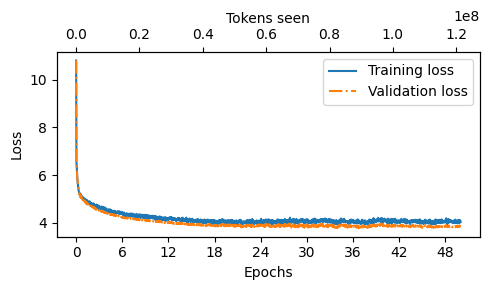

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [ ]:
# NEW: use CPU here as inference is cheap with
# this model and to ensure readers get same results in the
# remaining sections of this book
inference_device = torch.device("cpu")

model.to(inference_device)
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("once upon a time", tokenizer).to(inference_device),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 once upon a time, there was a little girl named Lily. She loved to play with her toys. One day, she saw a big box


In [ ]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        model.eval() # no dropout

        with torch.no_grad(): # no gradient
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Apply softmax to get probabilities
        # WE WILL CHANGE THIS PART
        # ----------------------------------------------------------------
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)
        # -------------------------------------------------------------------

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [ ]:
vocab = {
    "once": 0,
    "upon": 1,
    "time": 2,
    "there": 3,
    "was": 4,
    "little": 5,
    "girl": 6,
    "named": 7,
    "Lily": 8,
}

inverse_vocab = {v: k for k, v in vocab.items()}

# Suppose input is "every effort moves you", and the LLM
# returns the following logits for the next token:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item() # Top 1

# The next generated token is then as follows:
print(inverse_vocab[next_token_id])

there


In [ ]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

there


In [ ]:
def print_sampled_tokens(probas):
    torch.manual_seed(123) # Manual seed for reproducibility
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x once
0 x upon
0 x time
582 x there
2 x was
0 x little
0 x girl
343 x named
0 x Lily


In [ ]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

# Temperature values
temperatures = [1, 0.1, 5]  # Original, higher confidence, and lower confidence

# Calculate scaled probabilities
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

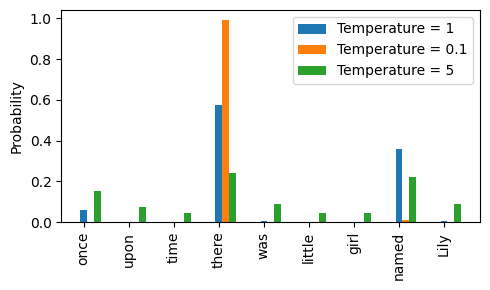

In [ ]:
# Plotting
import matplotlib.pyplot as plt
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

In [ ]:
print_sampled_tokens(scaled_probas[1]) # temp =0.1

0 x once
0 x upon
0 x time
985 x there
0 x was
0 x little
0 x girl
15 x named
0 x Lily


In [ ]:
print_sampled_tokens(scaled_probas[2]) # Temp = 5

165 x once
75 x upon
42 x time
239 x there
71 x was
46 x little
32 x girl
227 x named
103 x Lily


- In code, we can implement this as follows:

In [ ]:
next_token_logits

tensor([ 4.5100,  0.8900, -1.9000,  6.7500,  1.6300, -1.6200, -1.8900,  6.2800,
         1.7900])

In [ ]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)

print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [ ]:
new_logits = torch.where(
    condition=next_token_logits < 4.5100,
    input=torch.tensor(float("-inf")), # softmax(-inf) -> prob -> 0
    other=next_token_logits
)

print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


> NOTE:  
>
>  An alternative, slightly more efficient implementation of the previous code cell is the following:
>
> ```python
> new_logits = torch.full_like( # create tensor containing -inf values
>    next_token_logits, -torch.inf
>)   
> new_logits[top_pos] = next_token_logits[top_pos] # copy top k values into the -inf tensor
> ```
> <br>
> For more details, see https://github.com/rasbt/LLMs-from-scratch/discussions/326


In [ ]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


&nbsp;
### 5.3.3 Modifying the text generation function

- The previous two subsections introduced temperature sampling and top-k sampling
- Let's use these two concepts to modify the `generate_text_simple` function from chapter 4, creating a new `generate` function:

In [ ]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # New (not in book): numerical stability tip to get equivalent results on mps device
            # subtract rowwise max before softmax
            logits = logits - logits.max(dim=-1, keepdim=True).values

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [ ]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("once upon a time", tokenizer).to(inference_device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 once upon a time, there was a little girl named Lily. She had an orange color and


## 13. Saving the Checkpoint

The pretrained M05 checkpoint is saved here and reused later as the starting point for M07 supervised fine-tuning.

In [ ]:
model.state_dict()

OrderedDict([('tok_emb.weight',
              tensor([[ 0.2922, -0.0290, -0.1499,  ...,  1.1257,  0.2203,  0.3165],
                      [ 0.2565,  0.0426, -1.0331,  ...,  0.6767, -0.8842,  0.9115],
                      [-1.1881, -0.0611, -0.1219,  ..., -0.2874, -1.2589,  0.4721],
                      ...,
                      [ 0.5305, -0.0517, -1.0503,  ..., -0.6223, -0.6654,  0.4045],
                      [ 0.4388,  0.6784,  0.9509,  ...,  1.1457,  0.6250,  0.2657],
                      [-0.2212,  0.6177,  0.6035,  ...,  0.2937,  0.8122,  0.7400]])),
             ('pos_emb.weight',
              tensor([[ 0.3552, -0.2457, -1.3421,  ..., -0.1306, -1.4522,  0.6906],
                      [-0.0393, -0.7982, -1.3806,  ..., -0.3199,  0.4530, -0.3405],
                      [ 0.1149,  0.3546,  0.0111,  ..., -0.1056,  0.6323, -0.5961],
                      ...,
                      [-0.4369,  0.0813,  0.4854,  ...,  0.0458,  0.0408, -0.0249],
                      [-0.5726, -0.0363

In [ ]:
torch.save(model.state_dict(), "model.pth")

In [ ]:
model = GPTModel(GPT_CONFIG_124M)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

model.load_state_dict(torch.load("model.pth", map_location=device, weights_only=True))
model.eval();

Device: cuda


- It's common to train LLMs with adaptive optimizers like Adam or AdamW instead of regular SGD
- These adaptive optimizers store additional parameters for each model weight, so it makes sense to save them as well in case we plan to continue the pretraining later:

In [ ]:
optimizer.state_dict()

{'state': {0: {'step': tensor(59292.),
   'exp_avg': tensor([[-7.9729e-06, -9.9764e-06, -1.3219e-05,  ...,  4.8385e-06,
            -5.2771e-07, -1.0314e-05],
           [-4.0084e-06, -4.9347e-06,  1.3643e-06,  ...,  9.8243e-06,
            -3.2555e-06, -1.5526e-05],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           ...,
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [-2.8508e-33,  1.0132e-32, -5.6052e-45,  ..., -4.1139e-25,
            -4.6722e-34, -1.4756e-33],
           [-1.6785e-05,  1.1285e-05,  5.6273e-07,  ...,  1.9230e-06,
             7.3704e-07,  4.2284e-06]], device='cuda:0'),
   'exp_avg_sq': tensor([[1.9778e-09, 1.9310e-09, 1.4059e-09,  ..., 7.1628e-10, 5.5066e-10,
            1.6884e-09],
           [2.2730e-09, 2.6195e-09, 2.1882e-09,  ..., 3.2943e-09, 1.6248e-09,
            1.6861e-09],
           [0.0000e+00, 0.0000e+00, 0.000

In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer.pth"
)

In [ ]:
checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

# Instant Testing

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
print("Tokenizer loaded.")

Tokenizer loaded.


## 32. Instant Test — M05 Base Model

This section runs a quick generation test using the pretrained base model before instruction fine-tuning.

**Purpose**
- Verify that the M05 checkpoint loads correctly
- Check base text-generation behavior
- Compare later with the M07 fine-tuned model

In [9]:
import torch
import tiktoken
from previous_chapters import GPTModel, generate_text_simple

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = tiktoken.get_encoding("gpt2")

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    return torch.tensor(encoded).unsqueeze(0)

def token_ids_to_text(token_ids, tokenizer):
    return tokenizer.decode(token_ids.squeeze(0).tolist())

def generate(model, idx, max_new_tokens, context_size, eos_id=None):
    return generate_text_simple(
        model=model,
        idx=idx,
        max_new_tokens=max_new_tokens,
        context_size=context_size
    )

def format_input(entry):
    instruction_text = (
        "Below is an instruction that describes a task. "
        "Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    return instruction_text + input_text

print("Setup ready.")
print("Device:", device)

Setup ready.
Device: cpu


In [10]:
# ===== Instant Test:  Base Model =====

import torch
import previous_chapters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Use your exact M05 config
GPT_CONFIG_M05 = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 256,
    "n_heads": 8,
    "n_layers": 6,
    "drop_rate": 0.7,
    "qkv_bias": False
}

# Change this path if needed
m05_model_path = "/content/drive/MyDrive/SDAIA/model.pth"

m05_model = GPTModel(GPT_CONFIG_M05)
m05_state_dict = torch.load(m05_model_path, map_location="cpu")
m05_model.load_state_dict(m05_state_dict)
m05_model.to(device)
m05_model.eval()

m05_prompts = [
    "Once upon a time",
    "The little rabbit ran into the forest",
    "One sunny day, Tim found a strange box"
]

for i, prompt in enumerate(m05_prompts, start=1):
    with torch.no_grad():
        m05_token_ids = generate(
            model=m05_model,
            idx=text_to_token_ids(prompt, tokenizer).to(device),
            max_new_tokens=80,
            context_size=GPT_CONFIG_M05["context_length"],
            eos_id=50256
        )

    m05_generated_text = token_ids_to_text(m05_token_ids, tokenizer)

    print(f"===== BASE MODEL TEST {i} =====")
    print("Prompt:")
    print(prompt)
    print("\nGenerated Text:")
    print(m05_generated_text)
    print("\n" + "=" * 60 + "\n")

===== BASE MODEL TEST 1 =====
Prompt:
Once upon a time

Generated Text:
Once upon a time, there was a little girl named Lily. She loved to play with her toys. One day, she saw a big box with a big box. She wanted to play with her mom. She asked her mom if she could play with her mommy. Lily was very much. Lily was very much. Lily was very much.


"Mommy, but Lily said. She wanted to


===== BASE MODEL TEST 2 =====
Prompt:
The little rabbit ran into the forest

Generated Text:
The little rabbit ran into the forest. The bear was scared and scared. The bear was scared. The bear was scared and sad. The bear was sad. The bear was sad. The bear was sad and sad. The bear was sad. The bear was sad. The bear was sad. The bear was sad and sad. The bear was sad. The bear was sad. The bear was sad. The bear was sad and sad


===== BASE MODEL TEST 3 =====
Prompt:
One sunny day, Tim found a strange box

Generated Text:
One sunny day, Tim found a strange box. He wanted to play with his toys. He wante